Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


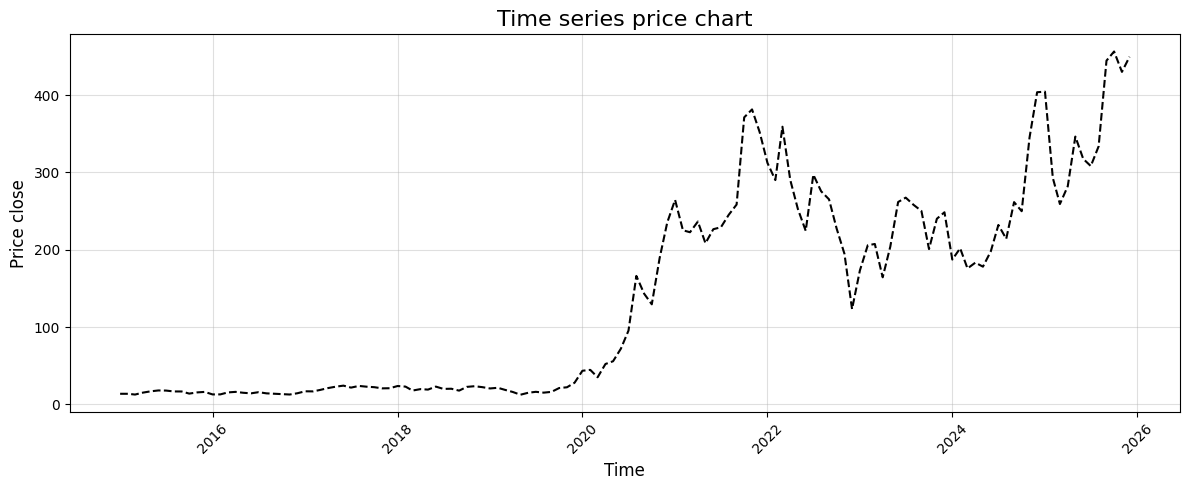

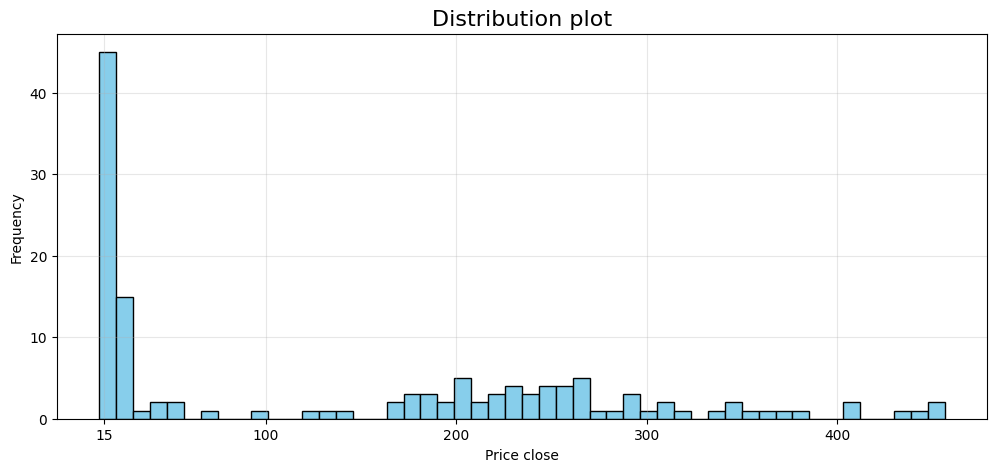

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.746
Method:                 Least Squares   F-statistic:                     384.9
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           1.12e-40
Time:                        06:37:10   Log-Likelihood:                -741.43
No. Observations:                 132   AIC:                             1487.
Df Residuals:                     130   BIC:                             1493.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -59.6068     11.741     -5.077      0.0

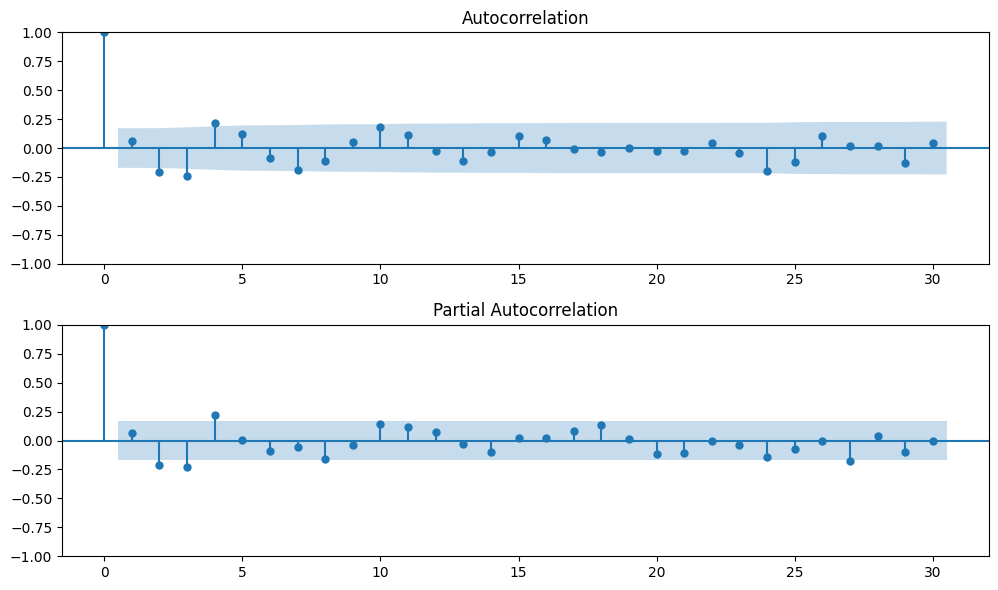

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                  132
Model:                 ARIMA(4, 1, 0)   Log Likelihood                -626.722
Date:                Tue, 02 Jun 2026   AIC                           1263.445
Time:                        06:37:10   BIC                           1277.821
Sample:                             0   HQIC                          1269.286
                                - 132                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1077      0.070      1.543      0.123      -0.029       0.244
ar.L2         -0.1350      0.084     -1.617      0.106      -0.299       0.029
ar.L3         -0.2125      0.062     -3.403      0.0

In [27]:
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
drive.mount('/content/drive')
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

df = pd.read_excel('/content/drive/MyDrive/colab đại học/môn kinh tế lượng tài chính/отчёт 1/Tesla.xlsx')

# phần 1
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Price'], linestyle='--', color='black')
plt.title('Time series price chart', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Price close', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.4)
plt.tight_layout()

plt.figure(figsize=(12,5))
plt.hist(df['Price'], bins=50, color='skyblue', edgecolor = 'black')
plt.title('Distribution plot', fontsize=16)
plt.xlabel('Price close')
plt.ylabel('Frequency')
plt.xticks([15,100,200,300,400])
plt.grid(True, alpha=0.3)
plt.show()

# Phần 2
df['Date']= pd.to_datetime(df['Date'],yearfirst=True)
df['t'] = range(1,len(df)+1)
y = df['Price']
x = df['t']
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())

# Phần 3
# 3.1 test ADF
from statsmodels.tsa.stattools import adfuller
df['d_Price'] = df['Price'] - df['Price'].shift(1)
df = df.dropna()
for i in ['Price','d_Price']:
  adf = adfuller(df[i],maxlag=None, regression='c', autolag='AIC')
  print(i)
  print(f"ADF Statistic: {adf[0]}")
  print(f"p-value: {adf[1]}")

# 3.2 ACF và PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(df['d_Price'], lags=30, ax=ax[0])
plot_pacf(df['d_Price'], lags=30, ax=ax[1])
plt.tight_layout()
plt.show()
# 3.3 Model
model = ARIMA(y, order=(4, 1, 0)).fit()
print(model.summary())